# DMET with Conformations of cyclohexane

Reference: [Visualize Organic Chemistry](https://visualizeorgchem.com/animations/cyclohexane-conformers/)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import for a pretty jupyter notebook.
import json

# Molecule definition.
from tangelo import SecondQuantizedMolecule

# Use for comparison.
# Use for VQE ressources estimation vs DMET.
from tangelo.algorithms import FCISolver, SQDSolver

# The minimal import for DMET.
from tangelo.problem_decomposition import DMETProblemDecomposition

# Ability to change localization method.
from tangelo.problem_decomposition.dmet import Localization

/home/gopald/Documents/jetix/lib/python3.10/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.2, so it will not be used.
  warnings.warn(


In [3]:
import numpy as np
from ase.io import read
from pyscf import gto

#  Read the XYZ file with ASE
xyz_file = "cyclohexane_chair-flip.xyz"  # Path to your XYZ file
molecules = read(xyz_file, index=":")  # Read all frames as a list of Atoms objects

names = ["Chair", "Half-chair", "Twist-boat", "Boat"]
indices = [0, 24, 42, 58]
conformations = [molecules[i] for i in indices]

## DMET-CCSD

In [4]:
# Function to group CH2 units for a single frame
def group_ch2_units(atoms):
    # Get atomic symbols and positions
    symbols = atoms.get_chemical_symbols()  # ['C', 'C', ..., 'H', ...]
    positions = atoms.get_positions()  # Shape: (18, 3) for x, y, z in Ångstroms

    # Identify carbon and hydrogen indices
    carbon_indices = [i for i, s in enumerate(symbols) if s == "C"]  # Should be 6
    hydrogen_indices = [i for i, s in enumerate(symbols) if s == "H"]  # Should be 12

    # Initialize list to store CH2 groups: [(C_index, H1_index, H2_index), ...]
    ch2_groups = []

    # Step 2: For each carbon, find the two closest hydrogens
    for c_idx in carbon_indices:
        # Compute distances from this carbon to all hydrogens
        c_pos = positions[c_idx]
        distances = [
            np.linalg.norm(c_pos - positions[h_idx]) for h_idx in hydrogen_indices
        ]

        # Find the two closest hydrogens (C-H bond ~1.09 Å)
        sorted_hydrogens = sorted(zip(distances, hydrogen_indices), key=lambda x: x[0])
        closest_hydrogens = [
            h_idx for _, h_idx in sorted_hydrogens[:2]
        ]  # Take two closest

        # Verify distances are within C-H bond length (~0.9–1.2 Å)
        for dist, h_idx in sorted_hydrogens[:2]:
            if dist > 1.3:  # Threshold to avoid incorrect pairing
                print(
                    f"Warning: Hydrogen {h_idx} too far from carbon {c_idx} (distance: {dist:.2f} Å)"
                )

        # Store the CH2 group
        ch2_groups.append((c_idx, closest_hydrogens[0], closest_hydrogens[1]))

        # Remove used hydrogens to avoid reassignment
        hydrogen_indices = [h for h in hydrogen_indices if h not in closest_hydrogens]

    return ch2_groups, carbon_indices

In [5]:
# Process each frame and print CH2 groups
xyzs = []
for frame_idx, (name, atoms) in enumerate(zip(names, conformations)):
    print(f"\nConformation: {name}:")
    ch2_groups, carbon_indices = group_ch2_units(atoms)

    # Check if grouping was successful
    if ch2_groups is None:
        print(f"Skipping frame {frame_idx + 1} due to incorrect atom count")
        continue

    # Create ch2_xyz list: [(atom, (x, y, z)), ...] with 3 tuples per CH2 group
    ch2_xyz = []
    for i, (c_idx, h1_idx, h2_idx) in enumerate(ch2_groups):
        # Get coordinates for C, H1, H2
        c_pos = atoms.positions[c_idx]
        h1_pos = atoms.positions[h1_idx]
        h2_pos = atoms.positions[h2_idx]

        # Convert coordinates to tuples for the required format
        c_tuple = (
            "C",
            tuple(c_pos),
        )  # e.g., ("C", (-0.74196402, -0.39672572, 1.21379406))
        h1_tuple = ("H", tuple(h1_pos))
        h2_tuple = ("H", tuple(h2_pos))

        # Add the CH2 group as three tuples
        ch2_xyz.extend([c_tuple, h1_tuple, h2_tuple])

    xyzs.append(ch2_xyz)

    # Optional: Verify C-C distances for ring structure
    print("C-C distances for ring verification:")
    for i in range(len(carbon_indices)):
        c1_idx = carbon_indices[i]
        c2_idx = carbon_indices[(i + 1) % 6]  # Next carbon in ring (cyclic)
        dist = np.linalg.norm(atoms.positions[c1_idx] - atoms.positions[c2_idx])
        print(f"  C{c1_idx}-C{c2_idx}: {dist:.2f} Å")


Conformation: Chair:
C-C distances for ring verification:
  C0-C1: 1.53 Å
  C1-C2: 1.53 Å
  C2-C3: 1.53 Å
  C3-C4: 1.53 Å
  C4-C5: 1.53 Å
  C5-C0: 1.53 Å

Conformation: Half-chair:
C-C distances for ring verification:
  C0-C1: 1.53 Å
  C1-C2: 1.53 Å
  C2-C3: 1.53 Å
  C3-C4: 1.55 Å
  C4-C5: 1.56 Å
  C5-C0: 1.55 Å

Conformation: Twist-boat:
C-C distances for ring verification:
  C0-C1: 1.54 Å
  C1-C2: 1.53 Å
  C2-C3: 1.54 Å
  C3-C4: 1.55 Å
  C4-C5: 1.53 Å
  C5-C0: 1.55 Å

Conformation: Boat:
C-C distances for ring verification:
  C0-C1: 1.55 Å
  C1-C2: 1.53 Å
  C2-C3: 1.53 Å
  C3-C4: 1.55 Å
  C4-C5: 1.53 Å
  C5-C0: 1.53 Å


In [6]:
molecules = []
for mol_structure in xyzs:
    molecules.append(SecondQuantizedMolecule(mol_structure, q=0, spin=0, basis="sto3g"))

In [7]:
for mol in molecules:
    print(mol.mf_energy)

-231.48080953435397
-231.46273102383964
-231.47132923973766
-231.47013593093405


In [8]:
from tangelo.problem_decomposition.dmet import Localization

energies_dmet_ccsd = []
for name, mol in zip(names, molecules):
    print(f"\nConformation: {name}:")
    options_dmet = {
        "molecule": mol,
        # Fragment definition = CH2, CH2, CH2, CH2, CH2, CH2
        "fragment_atoms": [3] * 6,
        "fragment_solvers": "ccsd",
        "electron_localization": Localization.meta_lowdin,
    }

    dmet_ccsd = DMETProblemDecomposition(options_dmet)
    dmet_ccsd.build()
    energy = dmet_ccsd.simulate()
    energies_dmet_ccsd.append(energy)
    print(f"DMET energy (hartree): \t {energy}")

energies_dmet_ccsd = np.array(energies_dmet_ccsd)
with open("cyclohexane_dmet_ccsd_energies.npy", "wb") as f:
    np.save(f, energies_dmet_ccsd)


Conformation: Chair:
DMET energy (hartree): 	 -231.9360068903431

Conformation: Half-chair:
DMET energy (hartree): 	 -231.9204884900571

Conformation: Twist-boat:
DMET energy (hartree): 	 -231.92794540438342

Conformation: Boat:
DMET energy (hartree): 	 -231.92645772049232


## DMET-SQD

In [9]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator

backend_options = {
    "precision": "single",
    "max_parallel_threads": 12,
    "max_parallel_experiments": 0,
    "max_parallel_shots": 0,
    "fusion_enable": True,
    "fusion_threshold": 14,
    "fusion_max_qubit": 4,
    "matrix_product_state_max_bond_dimension": 16,
    "matrix_product_state_truncation_threshold": 1e-8,
    "mps_sample_measure_algorithm": "mps_apply_measure",
    "mps_parallel_threshold": 12,
    "mps_omp_threads": 12,
    "mps_lapack": False,
    "seed_simulator": 42,
}

aer_sim = AerSimulator(method="matrix_product_state", **backend_options)
aer_sim.set_max_qubits(200)
aer_sim.options.seed_simulator = 42

pm = generate_preset_pass_manager(
    backend=aer_sim, optimization_level=1, seed_transpiler=42
)

### Restricting the fragment active space

Problem decomposition is successful at reducing the problem size, but the subproblems still can demand too much resources for a quantum computer. It is possible to define an active space in each DMET fragment, and an example is shown below.

In [10]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=aer_sim)

sqd_backend_options = {"sampler": sampler, "pass_manager": pm, "n_shots": 5000}


def define_dmet_frag_as(homo_minus_m=0, lumo_plus_n=0):
    def callable_for_dmet_object(info_fragment):
        mf_fragment, _, _, _, _, _, _ = info_fragment

        n_molecular_orb = len(mf_fragment.mo_occ)

        n_lumo = mf_fragment.mo_occ.tolist().index(0.0)
        n_homo = n_lumo - 1

        frozen_orbitals = [
            n
            for n in range(n_molecular_orb)
            if n not in range(n_homo - homo_minus_m, n_lumo + lumo_plus_n + 1)
        ]

        return frozen_orbitals

    return callable_for_dmet_object


energies_dmet_sqd = []
for name, mol in zip(names, molecules):
    print(f"\nConformation: {name}:")
    options_dmet = {
        "molecule": mol,
        # Fragment definition = CH2, CH2, CH2, CH2, CH2, CH2
        "fragment_atoms": [3] * 6,
        # The fragment active space can be selected with a nested list on ints (corresponding
        # to orbital indices), or a function.
        "fragment_frozen_orbitals": [define_dmet_frag_as(0, 0)] * 6,
        "fragment_solvers": "sqd",
        "verbose": False,
        "solvers_options": {"backend_options": sqd_backend_options},
    }

    dmet_sqd = DMETProblemDecomposition(options_dmet)
    dmet_sqd.build()

    resources_dmet_sqd = dmet_sqd.get_resources()
    print(resources_dmet_sqd[0])

    energy = dmet_sqd.simulate()
    energies_dmet_sqd.append(energy)
    print(f"DMET energy (hartree): \t {energy}")

energies_dmet_sqd = np.array(energies_dmet_sqd)
with open("cyclohexane_dmet_sqd_energies.npy", "wb") as f:
    np.save(f, energies_dmet_sqd)


Conformation: Chair:
{'circuit_width': 4, 'circuit_depth': 10}
DMET energy (hartree): 	 -231.4823226933919

Conformation: Half-chair:
{'circuit_width': 4, 'circuit_depth': 10}
DMET energy (hartree): 	 -231.46637083989162

Conformation: Twist-boat:
{'circuit_width': 4, 'circuit_depth': 10}
DMET energy (hartree): 	 -231.4735637257462

Conformation: Boat:
{'circuit_width': 4, 'circuit_depth': 10}
DMET energy (hartree): 	 -231.4719459555478


## Plot

In [2]:
import numpy as np

indices = [0, 24, 42, 58]
hartree_to_kjmol = 2625.5

with open('cyclohexane_hf_energies.npy', 'rb') as f:
    hf_energies = np.load(f)
    hf_energies *= hartree_to_kjmol 

with open('cyclohexane_dmet_ccsd_energies.npy', 'rb') as f:
    dmet_ccsd_energies = np.load(f)
    dmet_ccsd_energies *= hartree_to_kjmol 

with open('cyclohexane_dmet_sqd_energies.npy', 'rb') as f:
    dmet_sqd_energies = np.load(f)
    dmet_sqd_energies *= hartree_to_kjmol 

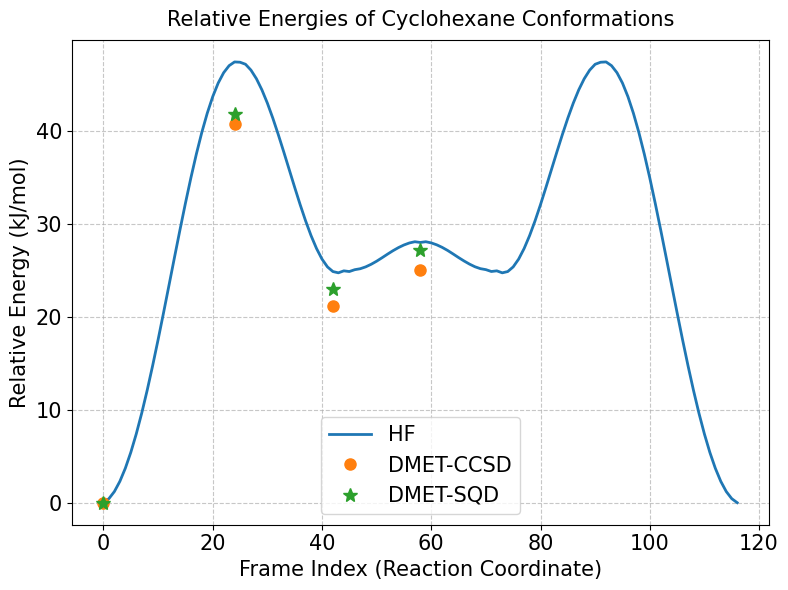

In [6]:
import matplotlib.pyplot as plt

rel_hf_energies = hf_energies - hf_energies[0]
rel_dmet_ccsd_energies = dmet_ccsd_energies - dmet_ccsd_energies[0]
rel_dmet_sqd_energies = dmet_sqd_energies - dmet_sqd_energies[0]

plt.figure(figsize=(8, 6))  # Set figure size for better readability
plt.plot(rel_hf_energies, linestyle='-', linewidth=2, markersize=6, label='HF')
plt.plot(indices, rel_dmet_ccsd_energies, marker='o', linestyle='None', markersize=8, label='DMET-CCSD')
plt.plot(indices, rel_dmet_sqd_energies, marker='*', linestyle='None', markersize=10, label='DMET-SQD')
plt.xlabel('Frame Index (Reaction Coordinate)', fontsize=15)
plt.ylabel('Relative Energy (kJ/mol)', fontsize=15)
plt.title('Relative Energies of Cyclohexane Conformations', fontsize=15, pad=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.tight_layout()
plt.savefig('cyclohexane_sqd')
plt.show()